Using 'MagpieData minimum GSbandgap' as the target variable.
Top 20 features selected by RFE: 
['MagpieData maximum NsValence', 'MagpieData mean NsValence', 'MagpieData mode NsValence', 'MagpieData minimum NpValence', 'MagpieData maximum NpValence', 'MagpieData mean NpValence', 'MagpieData minimum NpUnfilled', 'MagpieData maximum NpUnfilled', 'MagpieData mean NpUnfilled', 'MagpieData avg_dev NpUnfilled', 'MagpieData maximum NdUnfilled', 'MagpieData range NdUnfilled', 'MagpieData maximum NUnfilled', 'MagpieData range NUnfilled', 'MagpieData mean NUnfilled', 'MagpieData mode NUnfilled', 'MagpieData maximum GSbandgap', 'MagpieData mean GSbandgap', 'MagpieData minimum GSmagmom', 'MagpieData mean GSmagmom']


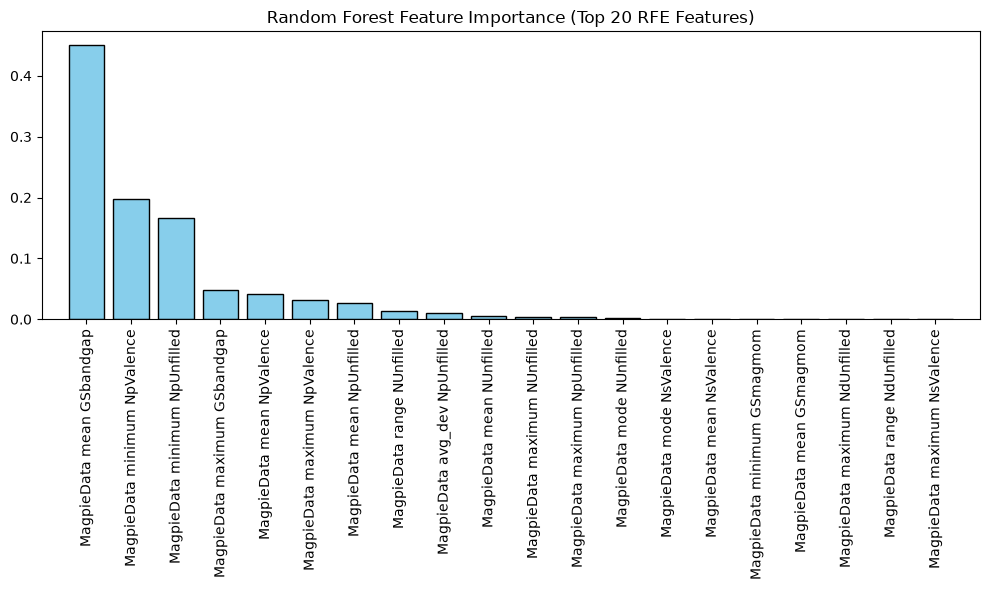

✅ Final curated feature set saved.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# 1. Load the filtered dataset
df = pd.read_csv('C:/Users/HP/Downloads/filtered_features_s20.csv')

# --- FIX: Identify the actual target column ---
# If your column is named something specific like 'MagpieData mean GSbandgap', 
# the code below will find it if 'target' is missing.
target_col = 'target'
if target_col not in df.columns:
    # Find any column that mentions 'bandgap' (adjust this if you are predicting something else)
    possible_targets = [col for col in df.columns if 'bandgap' in col.lower()]
    target_col = possible_targets[0] if possible_targets else df.columns[-1]

print(f"Using '{target_col}' as the target variable.")

# Drop rows missing the target variable
df = df.dropna(subset=[target_col])

# Separate features (X) and target (y)
X = df.drop(columns=[target_col, 'formula'], errors='ignore') 
y = df[target_col]

# Fill any missing feature values with the mean (to prevent Ridge from crashing)
X = X.fillna(X.mean(numeric_only=True))

# 2. Recursive Feature Elimination (RFE) with Ridge
# Reduce the dataset down to the top 20 features
ridge = Ridge(alpha=1.0)
rfe = RFE(estimator=ridge, n_features_to_select=20)
X_rfe = rfe.fit_transform(X, y)

# Get the names of the top 20 selected features
top_features = X.columns[rfe.support_]
print(f"Top 20 features selected by RFE: \n{list(top_features)}")

# 3. Random Forest Feature Importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_rfe, y)

# Extract and sort the importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 4. Preliminary Importance Bar Chart
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance (Top 20 RFE Features)")
plt.bar(range(X_rfe.shape[1]), importances[indices], align="center", color="skyblue", edgecolor="black")
plt.xticks(range(X_rfe.shape[1]), top_features[indices], rotation=90)
plt.xlim([-1, X_rfe.shape[1]])
plt.tight_layout()
plt.show()

# 5. Save the final curated dataset
# Safely include 'formula' and the actual target column if they exist
cols_to_keep = [col for col in ['formula', target_col] if col in df.columns] + list(top_features)
df_curated = df[cols_to_keep]

# Rename the target column back to 'target' for future scripts if you prefer:
if target_col != 'target':
    df_curated = df_curated.rename(columns={target_col: 'target'})

df_curated.to_csv('C:/Users/HP/Downloads/curated_features_s21.csv', index=False)
print("✅ Final curated feature set saved.")